In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, Input, Model 
from tensorflow.keras.layers import LSTM, Dense, Concatenate, TimeDistributed


In [2]:
# Load datasets
fred_md = pd.read_csv("FRED_MD.csv", index_col=0, parse_dates=True, date_format="%m/%d/%Y")
fred_qd = pd.read_csv("FRED_QD.csv", index_col=0, parse_dates=True, date_format="%m/%d/%Y")

# Drop metadata rows (first row for MD, first two for QD)
fred_md = fred_md.iloc[1:].apply(pd.to_numeric, errors='coerce')
fred_qd = fred_qd.iloc[2:].apply(pd.to_numeric, errors='coerce')

# Convert index to datetime (if not already)
fred_md.index = pd.to_datetime(fred_md.index)
fred_qd.index = pd.to_datetime(fred_qd.index)

In [3]:
# --- STEP 5: Define selected features ---
monthly_features = [
    # "VIXCLSx", "GS10", "TB3MS", "CPIAUCSL", "INDPRO", "M2SL",
    # "UNRATE", "PAYEMS", "HOUST", "RETAILx", "BUSINVx", "FEDFUNDS", "M1SL", "PERMIT"
    
    "VIXCLSx", "GS10", "TB3MS", "CPIAUCSL", "INDPRO",
    "UNRATE", "PAYEMS", "HOUST", "RETAILx", "BUSINVx", "FEDFUNDS", "PERMIT"
]
quarterly_features = ["GDPC1"]

# --- STEP 6: Subset features ---
monthly_selected = fred_md[monthly_features]
quarterly_selected = fred_qd[quarterly_features]

# --- STEP 7: Trim between 1962-07-01 and 2024-12-31 ---
start_date = pd.Timestamp("1962-07-01")
end_date = pd.Timestamp("2019-12-28")

monthly_trimmed = monthly_selected.loc[(monthly_selected.index >= start_date) & (monthly_selected.index <= end_date)]
quarterly_trimmed = quarterly_selected.loc[(quarterly_selected.index >= start_date) & (quarterly_selected.index <= end_date)]

# --- Final check ---
print("Date Range:", start_date.date(), "to", end_date.date())
print("Monthly shape:", monthly_trimmed.shape)
print("Quarterly shape:", quarterly_trimmed.shape)
print("Monthly missing values (null):\n", monthly_trimmed.isnull().sum())
print("Quarterly missing values (null):\n", quarterly_trimmed.isnull().sum())

print("Monthly missing values (na):\n", monthly_trimmed.isna().sum())
print("Quarterly missing values (na):\n", quarterly_trimmed.isna().sum())


Date Range: 1962-07-01 to 2019-12-28
Monthly shape: (690, 12)
Quarterly shape: (230, 1)
Monthly missing values (null):
 VIXCLSx     0
GS10        0
TB3MS       0
CPIAUCSL    0
INDPRO      0
UNRATE      0
PAYEMS      0
HOUST       0
RETAILx     0
BUSINVx     0
FEDFUNDS    0
PERMIT      0
dtype: int64
Quarterly missing values (null):
 GDPC1    0
dtype: int64
Monthly missing values (na):
 VIXCLSx     0
GS10        0
TB3MS       0
CPIAUCSL    0
INDPRO      0
UNRATE      0
PAYEMS      0
HOUST       0
RETAILx     0
BUSINVx     0
FEDFUNDS    0
PERMIT      0
dtype: int64
Quarterly missing values (na):
 GDPC1    0
dtype: int64


In [4]:
monthly_missing_trimmed = monthly_trimmed.isna().sum().sort_values(ascending=False)
quarterly_missing_trimmed = quarterly_trimmed.isna().sum().sort_values(ascending=False)

# Filter to only show features with any missing values
monthly_missing_trimmed = monthly_missing_trimmed[monthly_missing_trimmed > 0]
quarterly_missing_trimmed = quarterly_missing_trimmed[quarterly_missing_trimmed > 0]

monthly_missing_trimmed, quarterly_missing_trimmed


(Series([], dtype: int64), Series([], dtype: int64))

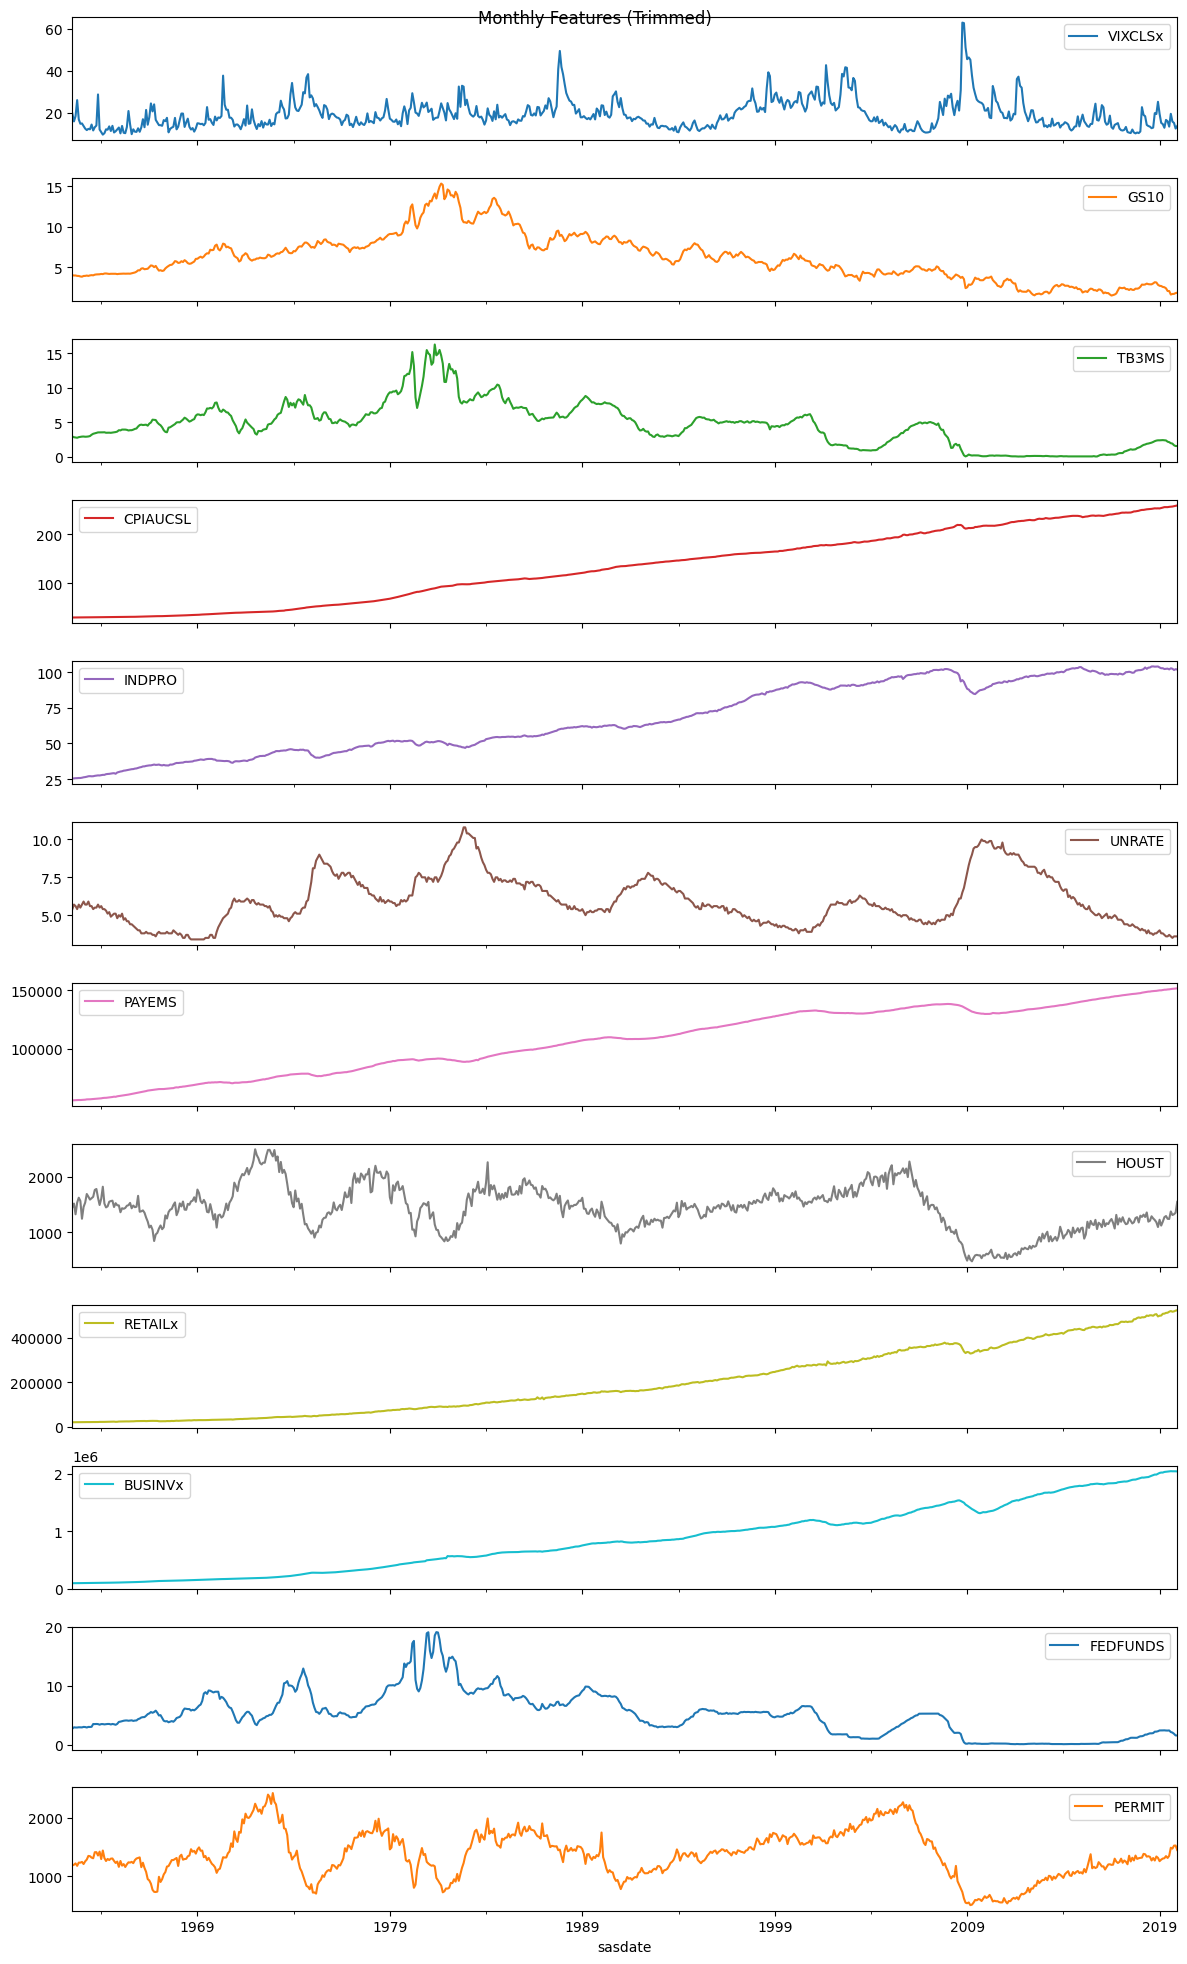

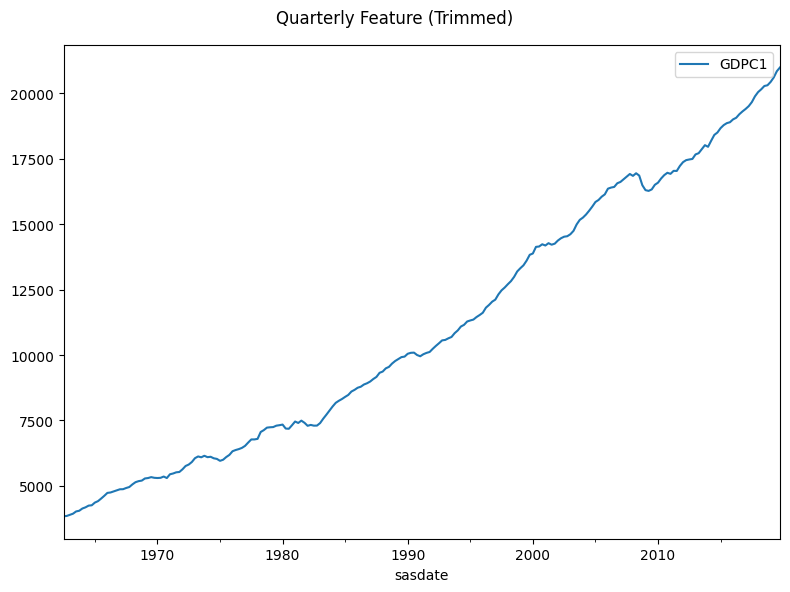

In [5]:
# --- Plot each feature in the monthly dataset ---
monthly_trimmed.plot(subplots=True, figsize=(12, 20), title="Monthly Features (Trimmed)")
plt.tight_layout()
plt.show()

# --- Plot each feature in the quarterly dataset ---
quarterly_trimmed.plot(subplots=True, figsize=(8, 6), title="Quarterly Feature (Trimmed)")
plt.tight_layout()
plt.show()

Model 1 preprocessing: repeating GDP values 

In [6]:
# Step 1: Repeat each quarterly observation 3 times
quarterly_repeated_values = quarterly_trimmed.loc[quarterly_trimmed.index.repeat(3)].reset_index(drop=True)

# Step 2: Use the last 747 months (to match the repeated quarterly series)
aligned_monthly = monthly_trimmed# .iloc[-len(quarterly_repeated_values):].copy()

if len(quarterly_repeated_values) != len(aligned_monthly):
    raise Exception("len(quarterly_repeated_values) != len(aligned_monthly)", len(quarterly_repeated_values), '!=', len(aligned_monthly))
else:
    print("quarterly and monthly have same len:", len(quarterly_repeated_values), '==', len(aligned_monthly))

# Step 3: Assign matching monthly index to repeated quarterly values
quarterly_repeated_values.index = aligned_monthly.index

# Final aligned series
aligned_quarterly = quarterly_repeated_values.copy()

# Confirm shapes
print(f"{aligned_monthly.shape=}"), print(F"{aligned_quarterly.shape=}")

# Output sample
print("aligned_monthly:", aligned_monthly, sep="\n")
print("aligned_quarterly:", aligned_quarterly, sep="\n")

quarterly and monthly have same len: 690 == 690
aligned_monthly.shape=(690, 12)
aligned_quarterly.shape=(690, 1)
aligned_monthly:
            VIXCLSx  GS10  TB3MS  CPIAUCSL    INDPRO  UNRATE  PAYEMS  HOUST  \
sasdate                                                                       
1962-07-01  19.5715  4.01   2.92    30.220   25.4023     5.4   55746   1450   
1962-08-01  15.7942  3.98   2.82    30.280   25.4292     5.7   55838   1517   
1962-09-01  18.3148  3.98   2.78    30.420   25.5905     5.6   55978   1324   
1962-10-01  25.9671  3.93   2.74    30.380   25.6174     5.4   56041   1533   
1962-11-01  16.7658  3.92   2.83    30.380   25.7249     5.7   56056   1622   
...             ...   ...    ...       ...       ...     ...     ...    ...   
2019-08-01  19.4147  1.63   1.95   256.036  102.7814     3.6  151171   1375   
2019-09-01  15.7324  1.70   1.89   256.430  102.4601     3.5  151365   1311   
2019-10-01  15.0714  1.71   1.65   257.155  101.5878     3.6  151460   1325   
2

Monthly: (482, 12) (103, 12) (105, 12)
Quarterly: (482, 1) (103, 1) (105, 1)
            VIXCLSx  GS10  TB3MS  CPIAUCSL   INDPRO  UNRATE  PAYEMS  HOUST  \
sasdate                                                                      
1962-07-01  19.5715  4.01   2.92     30.22  25.4023     5.4   55746   1450   
1962-08-01  15.7942  3.98   2.82     30.28  25.4292     5.7   55838   1517   
1962-09-01  18.3148  3.98   2.78     30.42  25.5905     5.6   55978   1324   
1962-10-01  25.9671  3.93   2.74     30.38  25.6174     5.4   56041   1533   
1962-11-01  16.7658  3.92   2.83     30.38  25.7249     5.7   56056   1622   
...             ...   ...    ...       ...      ...     ...     ...    ...   
2002-04-01  21.8145  5.21   1.71    179.30  89.5507     5.9  130615   1592   
2002-05-01  22.6300  5.16   1.73    179.50  89.9348     5.8  130632   1764   
2002-06-01  28.5990  4.93   1.70    179.60  90.6736     5.8  130673   1717   
2002-07-01  38.4972  4.65   1.68    180.00  90.6436     5.8  1305

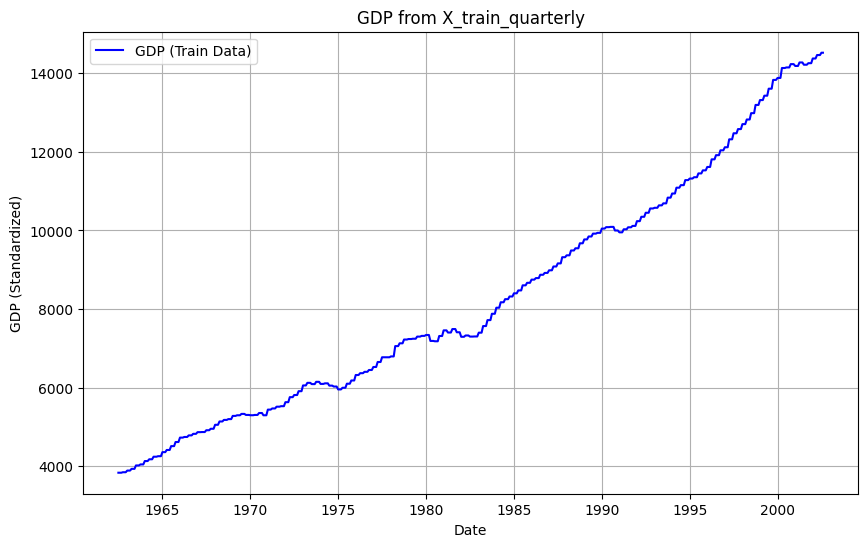

In [7]:
# Step 3: Split proportions
train_size = 0.7
val_size = 0.15
test_size = 0.15

# Step 4: Split indices
n = len(aligned_monthly)
train_end = int(n * train_size)
val_end = train_end + int(n * val_size)

# Step 5: Create splits
X_train_monthly = aligned_monthly.iloc[:train_end]
X_val_monthly = aligned_monthly.iloc[train_end:val_end]
X_test_monthly = aligned_monthly.iloc[val_end:]

X_train_quarterly = aligned_quarterly.iloc[:train_end]
X_val_quarterly = aligned_quarterly.iloc[train_end:val_end]
X_test_quarterly = aligned_quarterly.iloc[val_end:]

# Confirm shapes
print("Monthly:", X_train_monthly.shape, X_val_monthly.shape, X_test_monthly.shape)
print("Quarterly:", X_train_quarterly.shape, X_val_quarterly.shape, X_test_quarterly.shape)

print(X_train_monthly)
print(X_train_quarterly)

# Plot GDP from X_train_quarterly
plt.figure(figsize=(10, 6))
plt.plot(X_train_quarterly.index, X_train_quarterly["GDPC1"], label="GDP (Train Data)", color="blue")
plt.title("GDP from X_train_quarterly")
plt.xlabel("Date")
plt.ylabel("GDP (Standardized)")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Initialize the scaler
scaler_monthly = StandardScaler()
scaler_quarterly = StandardScaler()

# Fit the scaler on the training data and transform training, validation, and test sets
X_train_monthly_scaled = pd.DataFrame(scaler_monthly.fit_transform(X_train_monthly), 
                                      index=X_train_monthly.index, 
                                      columns=X_train_monthly.columns)

X_val_monthly_scaled = pd.DataFrame(scaler_monthly.transform(X_val_monthly), 
                                    index=X_val_monthly.index, 
                                    columns=X_val_monthly.columns)

X_test_monthly_scaled = pd.DataFrame(scaler_monthly.transform(X_test_monthly), 
                                     index=X_test_monthly.index, 
                                     columns=X_test_monthly.columns)

X_train_quarterly_scaled = pd.DataFrame(scaler_quarterly.fit_transform(X_train_quarterly), 
                                        index=X_train_quarterly.index, 
                                        columns=X_train_quarterly.columns)

X_val_quarterly_scaled = pd.DataFrame(scaler_quarterly.transform(X_val_quarterly), 
                                      index=X_val_quarterly.index, 
                                      columns=X_val_quarterly.columns)

X_test_quarterly_scaled = pd.DataFrame(scaler_quarterly.transform(X_test_quarterly), 
                                       index=X_test_quarterly.index, 
                                       columns=X_test_quarterly.columns)

# Confirm shapes
print("Monthly Scaled:", X_train_monthly_scaled.shape, X_val_monthly_scaled.shape, X_test_monthly_scaled.shape)
print("Quarterly Scaled:", X_train_quarterly_scaled.shape, X_val_quarterly_scaled.shape, X_test_quarterly_scaled.shape)

Monthly Scaled: (482, 12) (103, 12) (105, 12)
Quarterly Scaled: (482, 1) (103, 1) (105, 1)


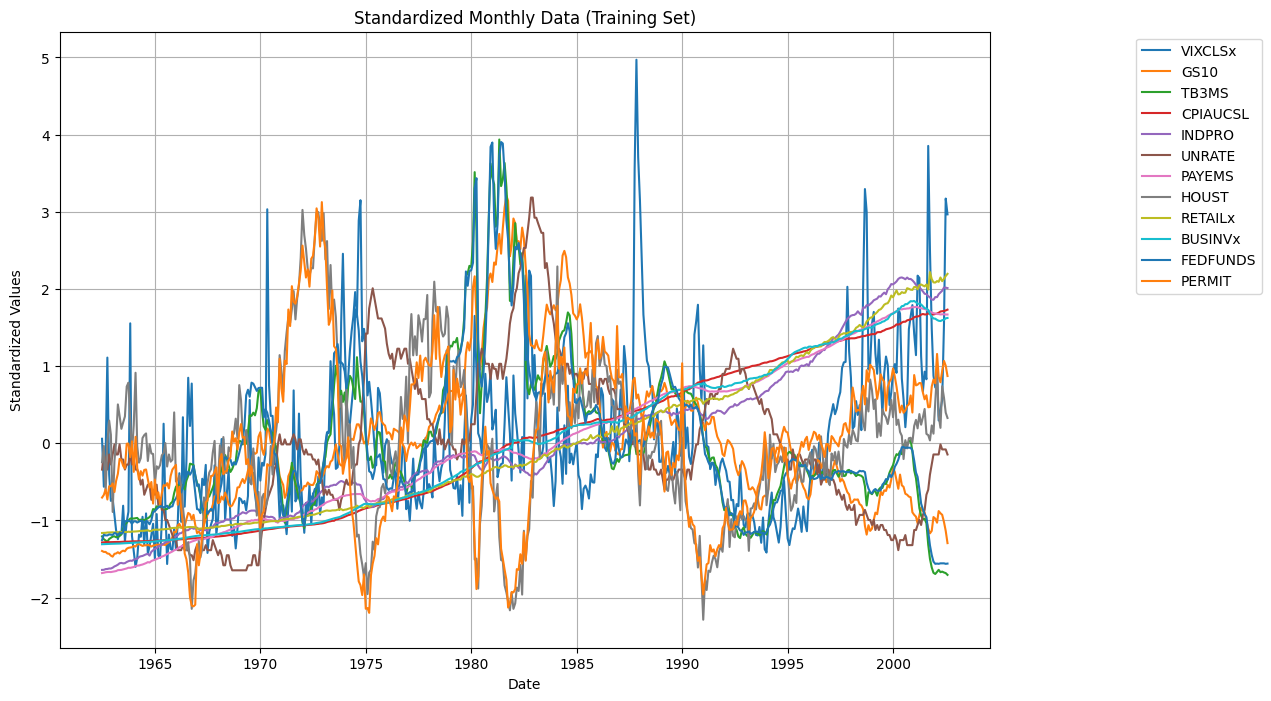

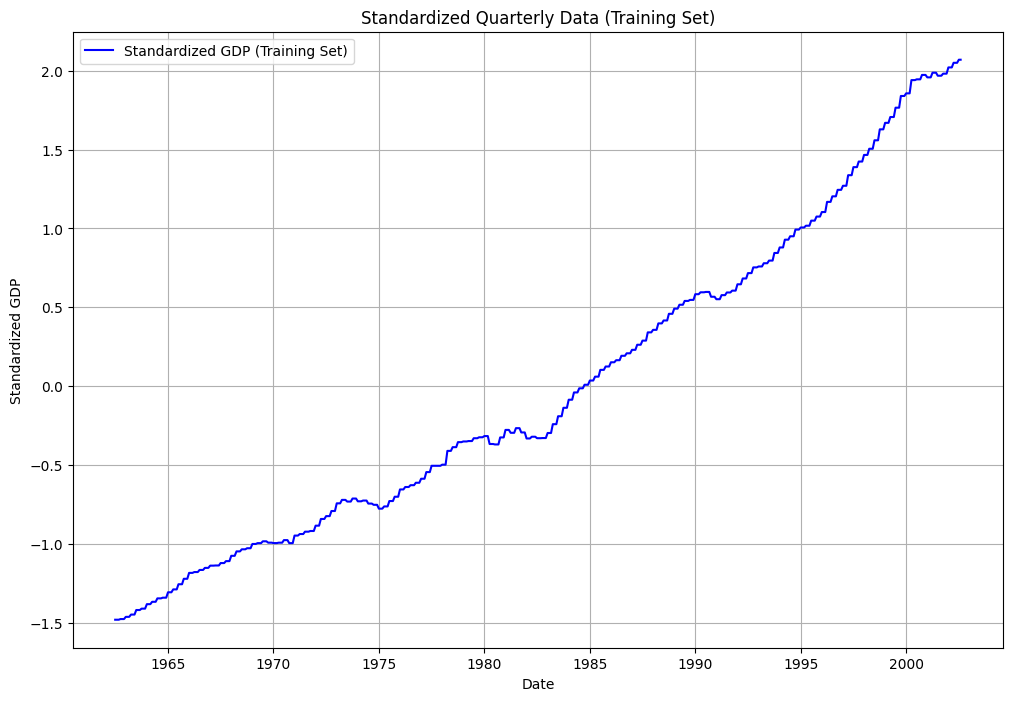

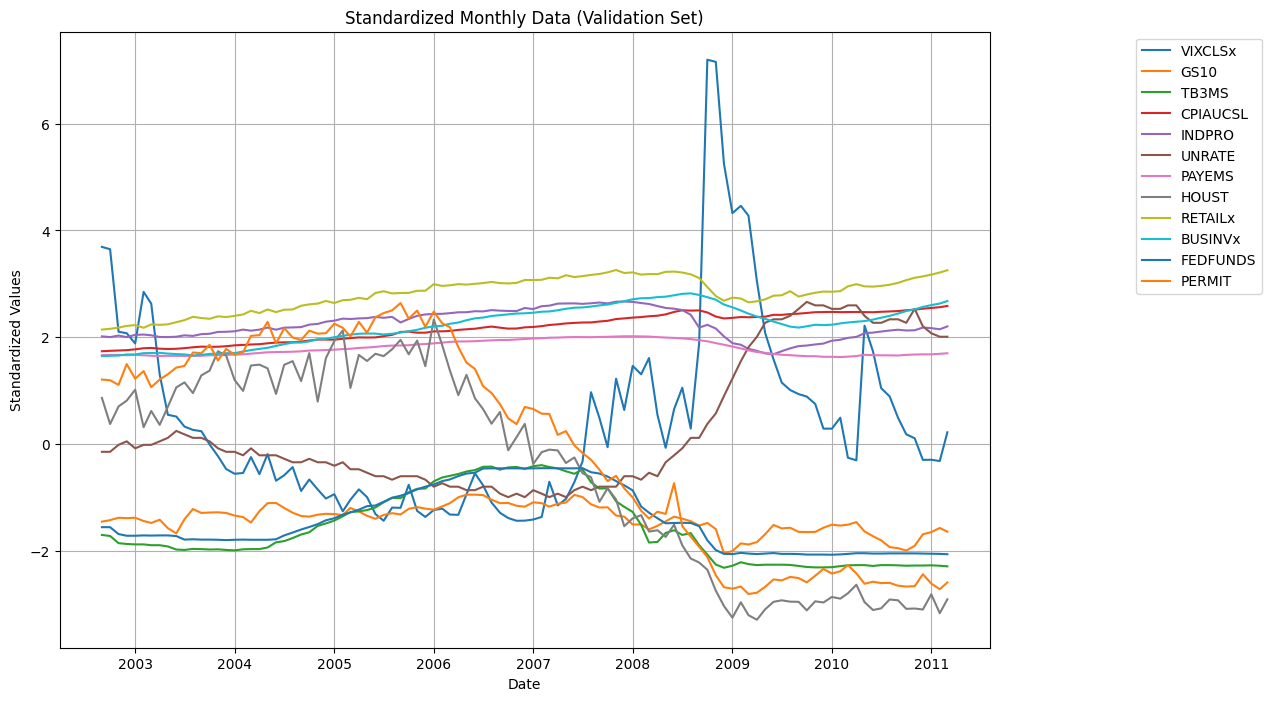

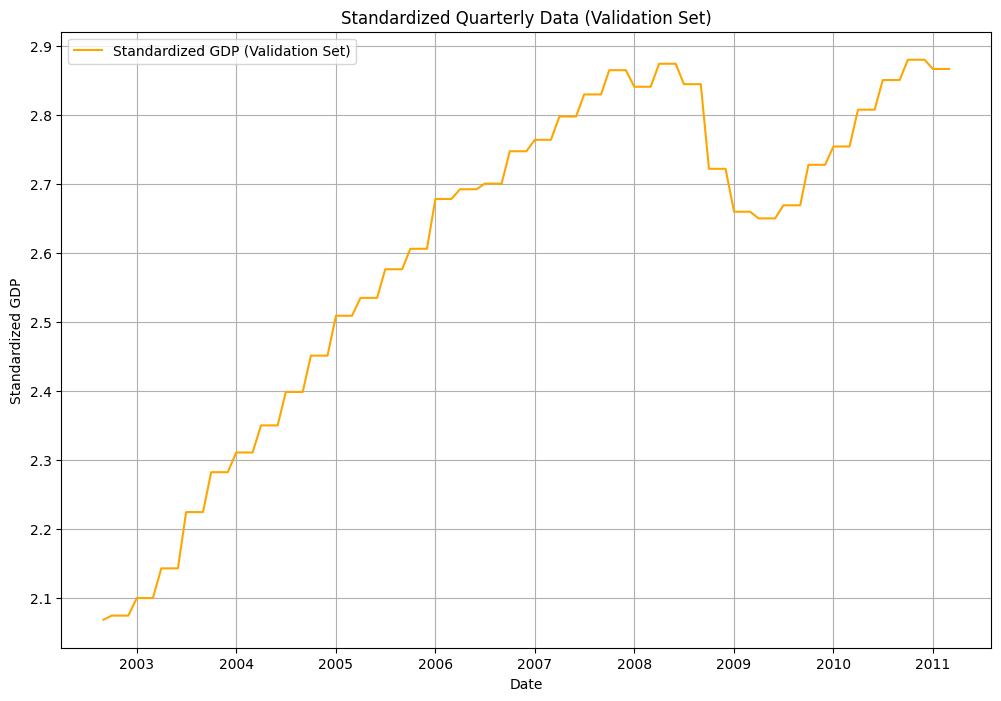

In [9]:
# Plot standardized monthly data
plt.figure(figsize=(12, 8))
for column in X_train_monthly_scaled.columns:
    plt.plot(X_train_monthly_scaled.index, X_train_monthly_scaled[column], label=column)
plt.title("Standardized Monthly Data (Training Set)")
plt.xlabel("Date")
plt.ylabel("Standardized Values")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1))
plt.grid(True)
plt.show()

# Plot standardized quarterly data
plt.figure(figsize=(12, 8))
plt.plot(X_train_quarterly_scaled.index, X_train_quarterly_scaled["GDPC1"], label="Standardized GDP (Training Set)", color="blue")
plt.title("Standardized Quarterly Data (Training Set)")
plt.xlabel("Date")
plt.ylabel("Standardized GDP")
plt.legend()
plt.grid(True)
plt.show()

# Plot standardized monthly validation data
plt.figure(figsize=(12, 8))
for column in X_val_monthly_scaled.columns:
    plt.plot(X_val_monthly_scaled.index, X_val_monthly_scaled[column], label=column)
plt.title("Standardized Monthly Data (Validation Set)")
plt.xlabel("Date")
plt.ylabel("Standardized Values")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1))
plt.grid(True)
plt.show()

# Plot standardized quarterly validation data
plt.figure(figsize=(12, 8))
plt.plot(X_val_quarterly_scaled.index, X_val_quarterly_scaled["GDPC1"], label="Standardized GDP (Validation Set)", color="orange")
plt.title("Standardized Quarterly Data (Validation Set)")
plt.xlabel("Date")
plt.ylabel("Standardized GDP")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# Step 1: Initialize empty lists for validation x and y
sequence_length = 12 # Number of months (so one year)

# Step 1: Initialize empty lists for x and y
x_data_monthly = []
x_data_quarterly = []
y_data = []

for i in range(len(X_train_monthly) - sequence_length - 3):  # -3 to account for the next quarter
    x_seq_monthly = X_train_monthly_scaled.iloc[i:i + sequence_length].values
    x_seq_quarterly = X_train_quarterly_scaled.iloc[i:i + sequence_length].values
    y_seq = X_train_quarterly_scaled.iloc[i + sequence_length + 2][["GDPC1"]]

    x_data_monthly.append(x_seq_monthly)
    x_data_quarterly.append(x_seq_quarterly)
    y_data.append(y_seq)

# Step 3: Convert lists to numpy arrays
x_train_md = np.array(x_data_monthly)
x_train_qd = np.array(x_data_quarterly)
y_train = np.array(y_data)

# Output shapes
print("x_train_md shape:", x_train_md.shape)
print("x_train_qd shape:", x_train_qd.shape)
print("y_train shape:", y_train.shape)

x_train_md shape: (467, 12, 12)
x_train_qd shape: (467, 12, 1)
y_train shape: (467, 1)


In [11]:
# Step 1: Initialize empty lists for validation x and y
sequence_length = 12 # Number of months (so one year)

# Step 1: Initialize empty lists for x and y
x_data_monthly_val = []
x_data_quarterly_val = []
y_data_val = []

for i in range(len(X_val_monthly) - sequence_length - 3):  # -3 to account for the next quarter
    x_seq_monthly_val = X_val_monthly_scaled.iloc[i:i + sequence_length].values
    x_seq_quarterly_val = X_val_quarterly_scaled.iloc[i:i + sequence_length].values
    y_seq_val = X_val_quarterly_scaled.iloc[i + sequence_length + 2][["GDPC1"]]

    x_data_monthly_val.append(x_seq_monthly_val)
    x_data_quarterly_val.append(x_seq_quarterly_val)
    y_data_val.append(y_seq_val)

# Step 3: Convert lists to numpy arrays
x_val_md = np.array(x_data_monthly_val)
x_val_qd = np.array(x_data_quarterly_val)
y_val = np.array(y_data_val)

# Output shapes
print("x_val_md shape:", x_val_md.shape)
print("x_val_qd shape:", x_val_qd.shape)
print("y_val shape:", y_val.shape)

x_val_md shape: (88, 12, 12)
x_val_qd shape: (88, 12, 1)
y_val shape: (88, 1)


In [29]:
# Step 1: Define inputs
monthly_input = Input(shape=(sequence_length, x_train_md.shape[2]), name="monthly_input")
quarterly_input = Input(shape=(sequence_length, x_train_qd.shape[2]), name="quarterly_input")

# Step 2: Concatenate monthly + quarterly input along feature axis
combined_input = Concatenate(axis=-1)([monthly_input, quarterly_input])

# Step 3: LSTM model
x = LSTM(64, return_sequences=False)(combined_input)[:, None]
output = TimeDistributed(Dense(1))(x)[..., 0]

# Step 4: Define model
model = Model(inputs=[monthly_input, quarterly_input], outputs=output)
model.compile(optimizer="adam", loss="mse")

# Summary
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ monthly_input       │ (None, 12, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quarterly_input     │ (None, 12, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 12, 13)    │          0 │ monthly_input[0]… │
│ (Concatenate)       │                   │            │ quarterly_input[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     19,968 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 1, 64)     │          0 │ lstm_1[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 1, 1)      │         65 │ get_item_2[0][0]  │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 1)         │          0 │ time_distributed… │
│ (GetItem)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,033 (78.25 KB)

 Trainable params: 20,033 (78.25 KB)

 Non-trainable params: 0 (0.00 B)

start taining
Initial validation Loss: 8.005718231201172
Initial train Loss: 1.093752145767212
Epoch 1/15
 1/15 ━━━━━━━━━━━━━━━━━━━━ 11s 844ms/step - loss: 1.3091
Epoch 1: val_loss improved from inf to 0.49173, saving model to results/best_model_weights.weights.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5885 - val_loss: 0.4917
Epoch 2/15
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0778
Epoch 2: val_loss did not improve from 0.49173
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0609 - val_loss: 1.3772
Epoch 3/15
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0083
Epoch 3: val_loss did not improve from 0.49173
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0135 - val_loss: 1.0426
Epoch 4/15
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0045
Epoch 4: val_loss did not improve from 0.49173
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0047 - val_loss: 0.9623
Epoch 5/15
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0030
Epoch 5: val_loss did not improve from

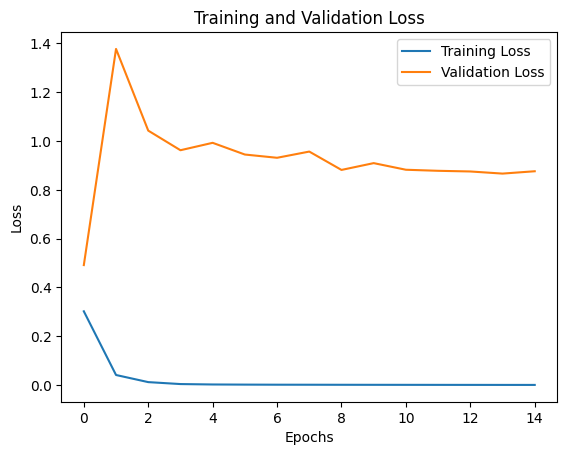

Validation Loss: 0.876133382320404
Train Loss: 0.0007850814145058393


In [30]:
# Step 1: Train the model
print("start taining")

# Step 3: Evaluate the model on validation data
initial_val_loss = model.evaluate([x_val_md, x_val_qd], y_val, verbose=0)
print(f"Initial validation Loss: {initial_val_loss}")
initial_train_loss = model.evaluate([x_train_md, x_train_qd], y_train, verbose=0)
print(f"Initial train Loss: {initial_train_loss}")

# Save the best model weights during training
checkpoint_filepath = 'results/best_model_weights.weights.h5'
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    [x_train_md, x_train_qd],  # Inputs: monthly and quarterly sequences
    y_train,                  # Target: next quarter GDP
    validation_data=([x_val_md, x_val_qd], y_val),  # Validation data
    epochs=15,               # Number of epochs
    batch_size=32,           # Batch size
    verbose=1,               # Verbosity level
    shuffle=True,            # Shuffle the data before each epoch
    callbacks=[model_checkpoint_callback]  # Save the best model weights
)

# Step 2: Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Step 3: Evaluate the model on validation data
val_loss = model.evaluate([x_val_md, x_val_qd], y_val, verbose=0)
print(f"Validation Loss: {val_loss}")
train_loss = model.evaluate([x_train_md, x_train_qd], y_train, verbose=0)
print(f"Train Loss: {train_loss}")

Calculate true GDP mse

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
RMSE (real): 48.10383066154869
MAE (real): 2163.930997247869
GDP range: 15162.76 to 16960.864


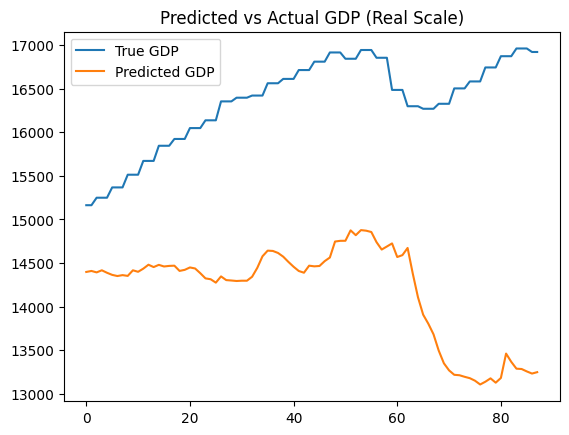

In [27]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error# Load the best model weights after training
model.load_weights(checkpoint_filepath)
y_pred = model.predict([x_val_md, x_val_qd])

y_pred_inv = scaler_quarterly.inverse_transform(y_pred)
y_true_inv = scaler_quarterly.inverse_transform(y_val)


rmse_real = root_mean_squared_error(y_true_inv, y_pred_inv) ** 0.5
mae_real = mean_absolute_error(y_true_inv, y_pred_inv)
print("RMSE (real):", rmse_real)	
print("MAE (real):", mae_real)

# Plot
print("GDP range:", y_true_inv.min(), "to", y_true_inv.max())

plt.plot(y_true_inv, label="True GDP")
plt.plot(y_pred_inv, label="Predicted GDP")
plt.title("Predicted vs Actual GDP (Real Scale)")
plt.legend()
plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
RMSE (real): 76.10570332850874
MAE (real): 58.41683203125002
GDP range: 4023.755 to 14519.633000000002


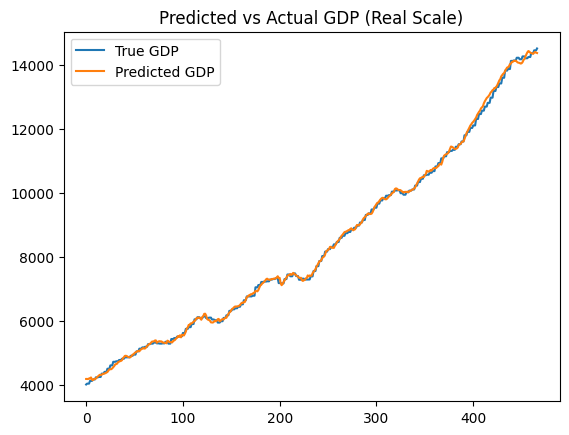

In [28]:
model.load_weights(checkpoint_filepath)
y_pred = model.predict([x_train_md, x_train_qd])

y_pred_inv = scaler_quarterly.inverse_transform(y_pred)
y_true_inv = scaler_quarterly.inverse_transform(y_train)

rmse_real = root_mean_squared_error(y_true_inv, y_pred_inv)
mae_real = mean_absolute_error(y_true_inv, y_pred_inv)
print("RMSE (real):", rmse_real)	
print("MAE (real):", mae_real)

# Plot
print("GDP range:", y_true_inv.min(), "to", y_true_inv.max())

plt.plot(y_true_inv, label="True GDP")
plt.plot(y_pred_inv, label="Predicted GDP")
plt.title("Predicted vs Actual GDP (Real Scale)")
plt.legend()
plt.show()

y_val:
[[2.28256385]
 [2.28256385]
 [2.31110414]
 [2.31110414]
 [2.31110414]
 [2.350357  ]
 [2.350357  ]
 [2.350357  ]
 [2.3987775 ]
 [2.3987775 ]
 [2.3987775 ]
 [2.4513475 ]
 [2.4513475 ]
 [2.4513475 ]
 [2.50909475]
 [2.50909475]
 [2.50909475]
 [2.5350225 ]
 [2.5350225 ]
 [2.5350225 ]
 [2.57647933]
 [2.57647933]
 [2.57647933]
 [2.60609154]
 [2.60609154]
 [2.60609154]
 [2.67820659]
 [2.67820659]
 [2.67820659]
 [2.69226282]
 [2.69226282]
 [2.69226282]
 [2.70042995]
 [2.70042995]
 [2.70042995]
 [2.74730884]
 [2.74730884]
 [2.74730884]
 [2.76385901]
 [2.76385901]
 [2.76385901]
 [2.79761574]
 [2.79761574]
 [2.79761574]
 [2.82959502]
 [2.82959502]
 [2.82959502]
 [2.8646738 ]
 [2.8646738 ]
 [2.8646738 ]
 [2.8406949 ]
 [2.8406949 ]
 [2.8406949 ]
 [2.87400785]
 [2.87400785]
 [2.87400785]
 [2.8444458 ]
 [2.8444458 ]
 [2.8444458 ]
 [2.7218923 ]
 [2.7218923 ]
 [2.7218923 ]
 [2.65974675]
 [2.65974675]
 [2.65974675]
 [2.65007488]
 [2.65007488]
 [2.65007488]
 [2.6690539 ]
 [2.6690539 ]
 [2.6690539 ]

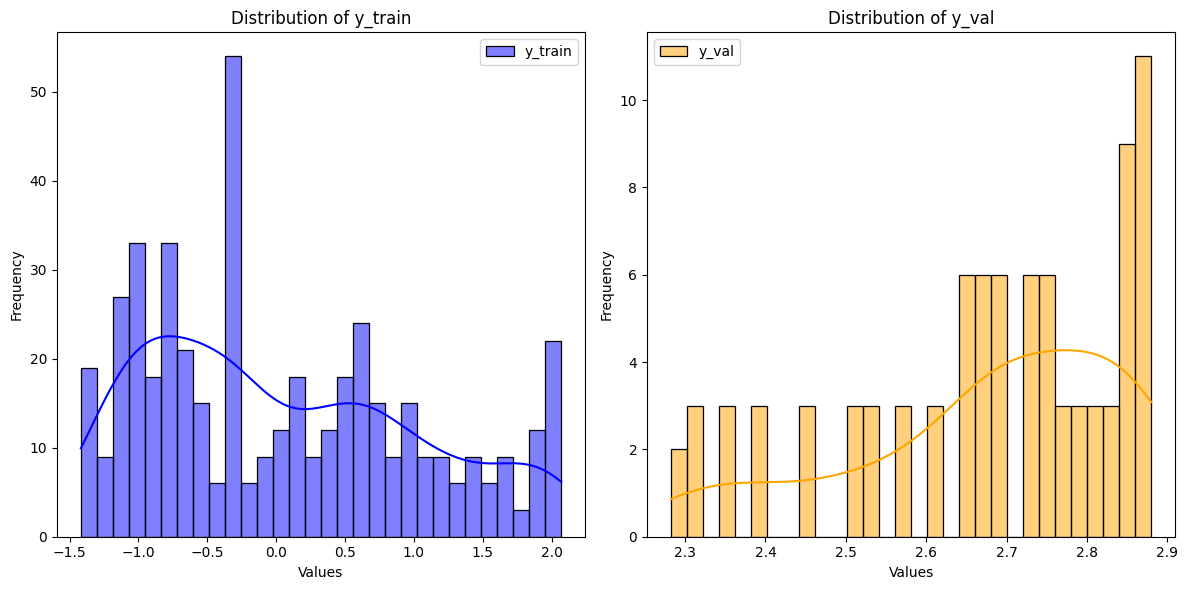

In [ ]:
print("y_val:")
print(y_val)

print("\ny_train:")
print(y_train)
# Visualize the distributions of y_train and y_val
plt.figure(figsize=(12, 6))

# Plot y_train distribution
plt.subplot(1, 2, 1)
sns.histplot(y_train.flatten(), kde=True, bins=30, color="blue", label="y_train")
plt.title("Distribution of y_train")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.legend()

# Plot y_val distribution
plt.subplot(1, 2, 2)
sns.histplot(y_val.flatten(), kde=True, bins=30, color="orange", label="y_val")
plt.title("Distribution of y_val")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()
